In [4]:
import rdkit

In [5]:
from rdkit import Chem

In [6]:
from rdkit.Chem import AllChem

# Anaconda 이용해서 scikit-learn 설치하기

- Random forest 이용해서 예측모델 중에서도 binding assay 결과를 예측하는 regression 모델(회귀 모델)을 만들 예정

- 회귀 모델을 만들기 위해서 가장  많이 사용되는 머신러닝 패키지 중에 하나인 scikit-learn 사용 예정. 아래ㅣ 코드로 scikit-learn 설치
    * !conda install -c conda-forge scikit-learn -y
    * "-y 옵션의 경우에는 무조건 yes! 설치를 하라는 뜻임."

In [7]:
!conda install -c conda-forge scikit-learn -y 

^C


- 위의 경고는 에러가 아니라 최신 버전으로 업데이트하라는 안내

In [8]:
conda update -n base -c defaults conda

^C

Note: you may need to restart the kernel to use updated packages.


In [9]:
import sklearn
print(sklearn.__version__)

1.7.2


In [10]:
import conda
print(conda.__version__)

ModuleNotFoundError: No module named 'conda'

In [11]:
from rdkit import DataStructs
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.GraphDescriptors import (BalabanJ, BertzCT, Chi0, Chi0n, Chi0v, Chi1,
                                         Chi1n, Chi1v, Chi2n, Chi2v, Chi3n, Chi3v, Chi4n, Chi4v,
                                         HallKierAlpha, Ipc, Kappa1, Kappa2, Kappa3)

from rdkit.Chem.EState.EState_VSA import (EState_VSA1, EState_VSA10, EState_VSA11, EState_VSA2, EState_VSA3,
                                          EState_VSA4, EState_VSA5, EState_VSA6, EState_VSA7, EState_VSA8, EState_VSA9,
                                          VSA_EState1, VSA_EState10, VSA_EState2, VSA_EState3, VSA_EState4, VSA_EState5,
                                          VSA_EState6, VSA_EState7, VSA_EState8, VSA_EState9,)

from rdkit.Chem.Descriptors import (ExactMolWt, MolWt, HeavyAtomMolWt, MaxAbsPartialCharge, MinPartialCharge,
                                    MaxPartialCharge, MinAbsPartialCharge, NumRadicalElectrons, NumValenceElectrons)

from rdkit.Chem.EState.EState import (MaxAbsEStateIndex, MaxEStateIndex, MinAbsEStateIndex, MinEStateIndex,)

from rdkit.Chem.Lipinski import (FractionCSP3, HeavyAtomCount, NHOHCount, NOCount, NumAliphaticCarbocycles,
                                 NumAliphaticHeterocycles, NumAliphaticRings, NumAromaticCarbocycles, NumAromaticHeterocycles,
                                 NumAromaticRings, NumHAcceptors, NumHDonors, NumHeteroatoms, RingCount,
                                 NumRotatableBonds, NumSaturatedCarbocycles, NumSaturatedHeterocycles, NumSaturatedRings,)

from rdkit.Chem.Crippen import (MolLogP, MolMR, )

from rdkit.Chem.MolSurf import (LabuteASA, PEOE_VSA1, PEOE_VSA10, PEOE_VSA11, PEOE_VSA12, PEOE_VSA13, PEOE_VSA14,
                                PEOE_VSA2, PEOE_VSA3,PEOE_VSA4, PEOE_VSA5, PEOE_VSA6, PEOE_VSA7, PEOE_VSA8, PEOE_VSA9,
                                SMR_VSA1, SMR_VSA10, SMR_VSA2, SMR_VSA3, SMR_VSA4, SMR_VSA5, SMR_VSA6,
                                SMR_VSA7, SMR_VSA8, SMR_VSA9, SlogP_VSA1, SlogP_VSA10, SlogP_VSA11, SlogP_VSA12,
                                SlogP_VSA2, SlogP_VSA3,SlogP_VSA4, SlogP_VSA5, SlogP_VSA6, SlogP_VSA7, SlogP_VSA8,
                                SlogP_VSA9, TPSA, )

from rdkit.Chem.Fragments import (fr_Al_COO, fr_Al_OH, fr_Al_OH_noTert, fr_ArN, fr_Ar_COO, fr_Ar_N, fr_Ar_NH,
 fr_Ar_OH, fr_COO, fr_COO2, fr_C_O, fr_C_O_noCOO, fr_C_S, fr_HOCCN, fr_Imine, fr_NH0, fr_NH1,
 fr_NH2, fr_N_O, fr_Ndealkylation1, fr_Ndealkylation2, fr_Nhpyrrole, fr_SH, fr_aldehyde, fr_alkyl_carbamate,
 fr_alkyl_halide, fr_allylic_oxid, fr_amide, fr_amidine, fr_aniline, fr_aryl_methyl, fr_azide, fr_azo, fr_barbitur,
 fr_benzene, fr_benzodiazepine, fr_bicyclic, fr_diazo, fr_dihydropyridine, fr_epoxide, fr_ester, fr_ether, fr_furan,
 fr_guanido, fr_halogen, fr_hdrzine, fr_hdrzone, fr_imidazole, fr_imide, fr_isocyan, fr_isothiocyan, fr_ketone,
 fr_ketone_Topliss, fr_lactam, fr_lactone, fr_methoxy, fr_morpholine, fr_nitrile, fr_nitro, fr_nitro_arom,
 fr_nitro_arom_nonortho, fr_nitroso, fr_oxazole, fr_oxime, fr_para_hydroxylation, fr_phenol,
 fr_phenol_noOrthoHbond, fr_phos_acid, fr_phos_ester, fr_piperdine, fr_piperzine, fr_priamide, fr_prisulfonamd,
 fr_pyridine, fr_quatN, fr_sulfide, fr_sulfonamd, fr_sulfone, fr_term_acetylene, fr_tetrazole, fr_thiazole, fr_thiocyan,
 fr_thiophene, fr_unbrch_alkane, fr_urea)

# Descriptor 계산 수행 함수. 
def calc_descriptors(mol):
    if mol is None:
        print("Molecule is None!")
        return None
    else:
        AllChem.ComputeGasteigerCharges(mol)
        finger = [
            BalabanJ(mol) , # 0
            BertzCT(mol) , # 1
            Chi0(mol) , # 2
            Chi0n(mol) , # 3
            Chi0v(mol) , # 4
            Chi1(mol) , # 5
            Chi1n(mol) , # 6
            Chi1v(mol) , # 7
            Chi2n(mol) ,
            Chi2v(mol) ,
            Chi3n(mol) ,
            Chi3v(mol) ,
            Chi4n(mol) ,
            Chi4v(mol) ,
            EState_VSA1(mol) ,
            EState_VSA10(mol) ,
            EState_VSA11(mol) ,
            EState_VSA2(mol) ,
            EState_VSA3(mol) ,
            EState_VSA4(mol) ,
            EState_VSA5(mol) ,
            EState_VSA6(mol) ,
            EState_VSA7(mol) ,
            EState_VSA8(mol) ,
                EState_VSA9(mol) ,
                ExactMolWt(mol) ,
                FractionCSP3(mol) ,
                HallKierAlpha(mol) ,
                HeavyAtomCount(mol) ,
                HeavyAtomMolWt(mol) ,
                # Ipc(mol) ,
                Kappa1(mol) ,
                Kappa2(mol) ,
                Kappa3(mol) ,
                LabuteASA(mol) ,
                MaxAbsEStateIndex(mol) ,
                MaxAbsPartialCharge(mol) ,
                MaxEStateIndex(mol) ,
                MaxPartialCharge(mol) ,
                MinAbsEStateIndex(mol) ,
                MinAbsPartialCharge(mol) ,
                MinEStateIndex(mol) ,
                MinPartialCharge(mol) ,
                MolLogP(mol) ,
                MolMR(mol) ,
                MolWt(mol) ,
                NHOHCount(mol) ,
                NOCount(mol) ,
                NumAliphaticCarbocycles(mol) ,
                NumAliphaticHeterocycles(mol) ,
                NumAliphaticRings(mol) ,
                NumAromaticCarbocycles(mol) ,
                NumAromaticHeterocycles(mol) ,
                NumAromaticRings(mol) ,
                NumHAcceptors(mol) ,
                NumHDonors(mol) ,
                NumHeteroatoms(mol) ,
                NumRadicalElectrons(mol) ,
                NumRotatableBonds(mol) ,
                NumSaturatedCarbocycles(mol) ,
                NumSaturatedHeterocycles(mol) ,
                NumSaturatedRings(mol) ,
                NumValenceElectrons(mol) ,
                PEOE_VSA1(mol) ,
                PEOE_VSA10(mol) ,
                PEOE_VSA11(mol) ,
                PEOE_VSA12(mol) ,
                PEOE_VSA13(mol) ,
                PEOE_VSA14(mol) ,
                PEOE_VSA2(mol) ,
                PEOE_VSA3(mol) ,
                PEOE_VSA4(mol) ,
                PEOE_VSA5(mol) ,
                PEOE_VSA6(mol) ,
                PEOE_VSA7(mol) ,
                PEOE_VSA8(mol) ,
                PEOE_VSA9(mol) ,
                RingCount(mol) ,
                SMR_VSA1(mol) ,
                SMR_VSA10(mol) ,
                SMR_VSA2(mol) ,
                SMR_VSA3(mol) ,
                SMR_VSA4(mol) ,
                SMR_VSA5(mol) ,
                SMR_VSA6(mol) ,
                SMR_VSA7(mol) ,
                SMR_VSA8(mol) ,
                SMR_VSA9(mol) ,
                SlogP_VSA1(mol) ,
                SlogP_VSA10(mol) ,
                SlogP_VSA11(mol) ,
                SlogP_VSA12(mol) ,
                SlogP_VSA2(mol) ,
                SlogP_VSA3(mol) ,
                SlogP_VSA4(mol) ,
                SlogP_VSA5(mol) ,
                SlogP_VSA6(mol) ,
                SlogP_VSA7(mol) ,
                SlogP_VSA8(mol) ,
                SlogP_VSA9(mol) ,
                TPSA(mol) ,
                VSA_EState1(mol) ,
                VSA_EState10(mol) ,
                VSA_EState2(mol) ,
                VSA_EState3(mol) ,
                VSA_EState4(mol) ,
                VSA_EState5(mol) ,
                VSA_EState6(mol) ,
                VSA_EState7(mol) ,
                VSA_EState8(mol) ,
                VSA_EState9(mol) ,
                fr_Al_COO(mol) ,
                fr_Al_OH(mol) ,
                fr_Al_OH_noTert(mol) ,
                fr_ArN(mol) ,
                fr_Ar_COO(mol) ,
                fr_Ar_N(mol) ,
                fr_Ar_NH(mol) ,
                fr_Ar_OH(mol) ,
                fr_COO(mol) ,
                fr_COO2(mol) ,
                fr_C_O(mol) ,
                fr_C_O_noCOO(mol) ,
                fr_C_S(mol) ,
                fr_HOCCN(mol) ,
                fr_Imine(mol) ,
                fr_NH0(mol) ,
                fr_NH1(mol) ,
                fr_NH2(mol) ,
                fr_N_O(mol) ,
                fr_Ndealkylation1(mol) ,
                fr_Ndealkylation2(mol) ,
                fr_Nhpyrrole(mol) ,
                fr_SH(mol) ,
                fr_aldehyde(mol) ,
                fr_alkyl_carbamate(mol) ,
                fr_alkyl_halide(mol) ,
                fr_allylic_oxid(mol) ,
                fr_amide(mol) ,
                fr_amidine(mol) ,
                fr_aniline(mol) ,
                fr_aryl_methyl(mol) ,
                fr_azide(mol) ,
                fr_azo(mol) ,
                fr_barbitur(mol) ,
                fr_benzene(mol) ,
                fr_benzodiazepine(mol) ,
                fr_bicyclic(mol) ,
                fr_diazo(mol) ,
                fr_dihydropyridine(mol) ,
                fr_epoxide(mol) ,
                fr_ester(mol) ,
                fr_ether(mol) ,
                fr_furan(mol) ,
                fr_guanido(mol) ,
                fr_halogen(mol) ,
                fr_hdrzine(mol) ,
                fr_hdrzone(mol) ,
                fr_imidazole(mol) ,
                fr_imide(mol) ,
                fr_isocyan(mol) ,
                fr_isothiocyan(mol) ,
                fr_ketone(mol) ,
                fr_ketone_Topliss(mol) ,
                fr_lactam(mol) ,
                fr_lactone(mol) ,
                fr_methoxy(mol) ,
                fr_morpholine(mol) ,
                fr_nitrile(mol) ,
                fr_nitro(mol) ,
                fr_nitro_arom(mol) ,
                fr_nitro_arom_nonortho(mol) ,
                fr_nitroso(mol) ,
                fr_oxazole(mol) ,
                fr_oxime(mol) ,
                fr_para_hydroxylation(mol) ,
                fr_phenol(mol) ,
                fr_phenol_noOrthoHbond(mol) ,
                fr_phos_acid(mol) ,
                fr_phos_ester(mol) ,
                fr_piperdine(mol) ,
                fr_piperzine(mol) ,
                fr_priamide(mol) ,
                fr_prisulfonamd(mol) ,
                fr_pyridine(mol) ,
                fr_quatN(mol) ,
                fr_sulfide(mol) ,
                fr_sulfonamd(mol) ,
                fr_sulfone(mol) ,
                fr_term_acetylene(mol) ,
                fr_tetrazole(mol) ,
                fr_thiazole(mol) ,
                fr_thiocyan(mol) ,
                fr_thiophene(mol),
                fr_unbrch_alkane(mol) ,
                fr_urea(mol) , #rdkit properties # 196
                ]
        return finger  # finger 라는 리스트로 return

# JACK2 단백질의 Protein Assay 결과를 예측하는 Random Forest 모델 만들기.

- Random Forest 란?

  여러 개의 의사결정 나무(Decision Tree)를 배깅(Bagging) 방식으로 결합하여, 개별 나무의 과적합(Overfitting) 문제를 해결하고 예측 성능과 안정성을 높인 앙상블 학습 알고리즘입니다. 학습 데이터에서 무작위로 추출한 데이터 샘플(부트스트랩)과 특성(Feature)을 사용하여 나무를 학습시킨 후, 분류는 다수결(Voting), 회귀는 평균으로 최종 결과를 도출

- pIC50는 약물이나 화합물의 결합력(Binding Affinity) 또는 억제 효능을 나타내는 지표로, IC50(50% 억제 농도) 값의 음의 로그 값(-log10(IC50)))으로 정의.
- IC50 농도 단위가 몰 농도(M, molar)일 때 주로 사용하며, 값이 클수록 약물의 결합력(친화도)이 강하고 효능이 높음을 의미.

정의: pIC50 = -log10(IC50 in Molar)

의미: 약물 억제 효과를 더 작고 직관적인 숫자로 표현

해석: pIC50 값이 높을수록(A=9, B=6) 적은 농도로 50% 억제 효과를 나타내므로, 결합력(binding affinity)이 높고 효능이 강한 것.

In [ ]:
# JACK2 protein의 data(1911개)를 이용해서 새로운 분자가 주어졌을때, 그 분자의 activity를 예측하는 random forest 모델 만들 예정.

* Data를 다루기에 좋음 => Pandas package (python과 잘 연동되는 excel(spread sheet) library
 => 기회가 되면 해보기

In [12]:
# 파일 읽어들이기
smiles_list = []    # 비어있는 list 정의
pIC50_list = []    # 비어있는 list 정의
with open("data/jak2_data.csv") as fp:            # data 폴터 안의 jak2_data.csv 파일을 읽기 모드로 열고, 이 파일 객체를 fp라는 이름으로 부르겠다.
    for l in fp.readlines()[1:]:                  # fp.resdlines() => 파일의 모든 줄을 읽어와 리스트로 만든다. [1:] => 리스트의 두번째 줄(인덱스 1부터_두번째부터 끝까지 가져온다. (보통 첫 번째줄은 컬럼명인 헤이므로 제외)
        smiles, pIC50 = l.strip().split(',')      # l.split() => 줄 끝의 줄바꿈 문자(\n)나 공백 제거. .split(',') 쉼표(,)를 기준으 문자열 자르기 smiles, pIC50 = ... => 자른 두 값을 각각 smiles와 pIC50 변수 나누어 저장. 
        pIC50 = float(pIC50)                      # pIC50는 실수 값이기 때문에(현재 문자로 저장되어있음) , 실수 값으로 변환
        smiles_list.append(smiles)                # smiles에 해당하는 값을 smiles_list에 하나씩 저장
        pIC50_list.append(pIC50)                  # pIC50에 해당하는 값을 pIC50_list에 하나씩 저장



==> WARNING: A newer version of conda exists. <==
  current version: 4.8.2
  latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda




Solving environment: ...working... done

# All requested packages already installed.



<Python의 with문이란?>

with문은 파이썬에서 "자원을 사용한 후 자동으로 정리해주는 도구".

왜 쓰는가?

파일을 열면(open), 작업이 끝난 후 반드시 닫아줘야(close) 메모리 낭비나 파일 손상을 막을 수 있다.

with를 쓰지 않으면 매번 fp.close()를 직접 써야 하지만, with를 쓰면 블록이 끝나는 순간 파이썬이 알아서 파일을 닫아준다.

핵심 장점: 코드가 간결해지고, 도중에 에러가 발생해도 파일을 확실하게 닫아주어 안전하다.

In [ ]:
len(smiles_list)

In [ ]:
len(pIC50_list)

In [ ]:
smiles_list[0:2]     # 0번 부터 2번 직전(1번까지)를 의미

In [ ]:
smiles_list[1:2]

# SMILES를 Descriptor로 변환
=> 1911개의 분자를 1911개의 벡터(숫자 리스트)로 변환

In [13]:
desc = calc_descriptors(Chem.MolFromSmiles("c1ccccc1"))

In [14]:
desc

[3.000000000000001,
 71.96100505779535,
 4.242640687119286,
 3.464101615137755,
 3.464101615137755,
 3.0,
 2.0000000000000004,
 2.0000000000000004,
 1.1547005383792521,
 1.1547005383792521,
 0.6666666666666671,
 0.6666666666666671,
 0.38490017945975075,
 0.38490017945975075,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 36.39820241076966,
 0.0,
 0.0,
 78.046950192,
 0.0,
 -0.78,
 6,
 72.06599999999999,
 3.4115708812260532,
 1.6057694396735218,
 0.5823992601400448,
 37.43140311949697,
 2.0,
 0.062268570782092456,
 2.0,
 -0.062268570782092456,
 2.0,
 0.062268570782092456,
 2.0,
 -0.062268570782092456,
 1.6866,
 26.441999999999993,
 78.11399999999999,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 30,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 36.39820241076966,
 0.0,
 0.0,
 0.0,
 1,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 36.39820241076966,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 36.39820241076966,
 0.0,
 0.0,
 0.0,
 0.0,
 0.

In [15]:
len(desc)  # 195개의 실수(float)로 된 descriptor list로 변환됨.

195

-  TIP : tpdm 모듈을 사용하면 progress bar를 볼 수 있다.

-  #! conda install -c conda-forge tqdm -y 하면 설치가능!

In [ ]:
! conda install -c conda-forge tqdm -y

In [16]:
from tqdm import tqdm

In [20]:
dsec_list = []
for smiles in tqdm(smiles_list):     # tqdm 을 사용함으로써 progress 상황 알 수 있다.
    mol = Chem.MolFromSmiles(smiles) #SMILES -> Mol type으로 변경
    dsec = calc_descriptors(mol)
    dsec_list.append(dsec)

100%|██████████████████████████████████████████████████████████████████████████████| 1911/1911 [00:26<00:00, 73.25it/s]


In [21]:
dsec_list[0]

[1.6891010679640355,
 1139.9346654410272,
 17.27781011412252,
 12.955623583130881,
 14.588616744986334,
 12.116122967884975,
 7.503161722513579,
 9.865977781362865,
 5.3623467315570865,
 8.219283427004692,
 3.619036345691878,
 6.39779902625805,
 2.460132737297642,
 4.502492141959249,
 10.023291153407584,
 8.417796984328938,
 0.0,
 4.2091791775220795,
 11.381314269532023,
 16.59685292692952,
 11.336785877934737,
 41.90874168438704,
 30.33183534230805,
 14.690051906346504,
 0.0,
 367.04491865600005,
 0.0,
 -2.769999999999999,
 25,
 354.35100000000006,
 15.740008044893049,
 6.268385354767415,
 3.2392829946811608,
 148.61755337168788,
 12.35664883780775,
 0.27894233829193016,
 12.35664883780775,
 0.2708926724876687,
 0.28092580576256654,
 0.2708926724876687,
 -3.571131744721662,
 -0.27894233829193016,
 4.159100000000002,
 100.10150000000002,
 367.4550000000001,
 1,
 5,
 0,
 0,
 0,
 2,
 2,
 4,
 5,
 1,
 7,
 0,
 4,
 0,
 0,
 0,
 124,
 0.0,
 4.2091791775220795,
 0.0,
 0.0,
 10.023291153407584,


In [22]:
len(dsec_list)  # 전체 리스트에 담긴 '분자의 개수'입니다. (예: 1912개)

1911

In [24]:
len(dsec_list[0])  #  첫 번째 분자(dsec_list[0]) 하나가 가진 'Descriptor(특성)의 개수'입니다.

195

In [25]:
# sickit learn 에서 다루기 위해서는 NumPy array로 바꿔주는 것이 좋다.
# NumPy(Numeric Python) array는 수학적/과학적 연산을 빠르게하기 위해서 사용되는 rdkit의 외부 모듈

import numpy as np

# 1911개의 분자 객체에 대하여 195차원 벡터를 가지고 있기 때문에, 행렬 형태로 변환해 다루기 위함. 
# 현재 desc_list는 195차원의 리스트를 1911개 가지고 있다.

In [26]:
X = np.array(dsec_list) # 일반적으로 인풋 데이터 전체를 X 로 표현함. Input Feature

X

In [27]:
X.shape # 행은 각 분자, 열은 서로다른 물성

(1911, 195)

* 1911 X 195 행렬로 변환됨.
* 각 행은 하나의 분자에 해당
* 각 열은 하나의 물성에 해당.

* X = 일반적으로 인풋 데이터 전체를 X로 표현 (Input Feature)
* y = 예측하고자하는 타겟값

In [28]:
y = np.array(pIC50_list) # 예측하고자하는 목적 값을 y로 바꿔줌.

In [29]:
y

array([ 4.26,  4.34,  4.53, ..., 10.78, 10.97, 10.97])

In [30]:
y.shape

(1911,)

# 모델 학습 시키기

# 1. Random Forest 모델/알고리즘 (Machine Learing 알고리즘)

* 장점:
    * 정규화가 필요 없다 -> 각 column (물성)의 최대, 최소값 이 달라도 학습에 전혀 문제가 없다.
    * 범주형 데이터도 잘 다룬다. (숫자로 바꿀 수 없는 것)

In [31]:
from sklearn.ensemble import RandomForestRegressor as RFR

* RandomForeestRegressor 불러오는 방법
  sklearn.ensemble.RandomForestRegressor(n_estimators=n,...기타 옵션들)

여기서 argument에 해당하는 n_estimators=n 를 입력하지 않으면 default 모델이 생성된다.

In [32]:
# default 모델 생성
# instance 를 생성할 때, 아무런 argument(인자 혹은 숫자; 괄호 안에 적는 거) 를 주지 않으면 default 옵션으로 생성됨.
my_model = RFR() 

In [33]:
# my_model에 비어있는 RandomForestRegressor가 생성됨을 확인
my_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 2. 학습 데이터와 검증 데이터 준비

* 학습시킨 뒤, 학습이 잘 되었는지 확인하기 어렵기 때문에 검증하기 위한 검증 데이터는 학습 데이터와 한 묶음이다.
* 학습 데이터와 검증 데이터를 분리해주어야한다.
=> 이때 사용하는 코드:
from sklearn.model_selection import train_test_split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = n, random_state = m)

test_size = n : 검증용으로 이 중에서 몇%를 사용할 것인지 (100n% ; n=0.2 => 20%를 test로 사용)

random_state = m : 전체 X를 랜덤하게 어떤거는 train(학습)으로, 어떤거는 test(검증)으로 쓸건지를 분리할 것이기 때문에 매번 분리할때마다 달라지는데, 이걸 분리할때마다 달라지지 않게 하려면 m에 해당하는 숫자를 고정시켜주면 된다.


In [35]:
# train 데이터와 test 데이터를 분리하는 방법
# 아래의 train_test_split()의 return 값은 X-train, X-test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state = 42)

In [36]:
X_train.shape

(1528, 195)

In [37]:
X_test.shape

(383, 195)

## 3. 모델 학습

In [38]:
# fit이라는 함수를 통해 텅빈 리스트를 학습시킨다.
my_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


++ 추가 정보 ++

scikit-learn의 fit 함수가 작동할 때는 파이썬 수준에서 반복문을 돌리는게 아니라, 내부적으로 최적화된 C++나 Cython 코드로 한꺼번에 실행되기 때문에 이때는 verbose 옵션을 활용할 수 있다.

* 모델 생성 시 verbose=2 또는 3 설정 (숫자가 클수록 자세히 출력)
verbose = 0  (출력하지 않음 X)
verbose = 1  (정보를 상세하게 출력함)
verbose = 2  (정보를 함축적으로 출력함)

my_model = RFR(n_estimators=100, verbose=2)

<이때 n_estimators=n 에 해당하는 argument 생략하고 verbose만 적어도 실행된다.>
*  실행하면 트리 하나하나가 만들어지는 과정이 텍스트로 뜹니다.

my_model.fit(X_train, y_train)

In [39]:
my_model = RFR(verbose=2)

In [40]:
my_model.fit(X_train, y_train)

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    5.0s


building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   12.7s finished


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 4. 학습 끝, 검증 시작

scikit method 종류

1. apply(X) : 입력된 데이터(X)가 모델 내 각 나무(Tree)의 어느 잎 노드(Leaf node)에 최종적으로 도착하는지 그 인덱스를 알려준니다.
2. decision_path(X) : 데이터가 예측을 위해 나무의 뿌리부터 잎까지 이동하는 결정 경로를 보여주며, 어떤 조건(분기점)을 거쳤는지 추적할 때 쓴다.
3. fit(X, y[sample_weight]) : 모델 학습 명령어로, 준비한 문제(X)와 정답(y)을 모델에게 주어 데이터 사이의 패턴을 스스로 학습하게 만든다.
4. get_params([depp]) : 현재 모델에 설정된 하이퍼파라미터(설정값)들을 확인한다. (예: n_estimators가 몇으로 설정되어 있는지 등)
5. predict(X) : 학습된 모델을 이용해 새로운 데이터(X)의 정답을 예측한다. 회귀 모델이라면 수치를, 분류 모델이라면 클래스를 반환한다.
6. score(X, y[,sample_weight]) : 모델의 성능 점수를 계산한다. RandomForestRegressor에서는 기본적으로 R^2(결정계수) 점수를 계산해 모델이 얼마나 정확한지 알려준다.
7. set_params(**params) : 이미 만들어진 모델의 설정값을 수정할 때 쓴다. 모델을 새로 만들지 않고 파라미터만 슥 바꿀 수 있다.

In [41]:
# 예측을 시킬 때
y_pred = my_model.predict(X_test)

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [42]:
#y_pred에 예측값이 저장되어 있음.
y_pred

array([ 7.3456    ,  5.5682    , 10.05273333,  7.18700952,  6.56155   ,
        8.292475  ,  6.529     ,  6.52415   ,  7.46213833,  7.4809    ,
        7.1585    ,  6.5905    ,  7.9726    ,  5.9385    ,  6.5178    ,
        7.78921667,  7.3749    ,  7.06848333,  7.3701    ,  7.08372833,
        6.368     ,  6.75245   ,  7.32891167,  6.2822    ,  6.462525  ,
        6.46286667,  5.751975  ,  8.2914    ,  8.41933   ,  7.39105   ,
        6.54456667,  7.48409   ,  7.7435    ,  9.77175   ,  6.3647    ,
        7.16036667,  6.75400667,  7.65635   ,  7.2739    ,  6.9133    ,
        6.96656429,  6.44825   ,  7.3488    ,  7.5808    ,  7.69226667,
        7.63495833,  7.6032    ,  7.35746   ,  6.5797    ,  7.5509    ,
        7.5778    ,  6.65253571,  7.840275  ,  6.93055   ,  6.75045833,
        7.172     ,  7.38818   ,  8.3704    ,  6.51757833,  8.03027667,
        7.5241    ,  7.07258667,  6.85311667,  7.8245    ,  6.58135   ,
        7.8537    ,  6.97735833,  7.7986    ,  7.13159167,  8.59

## 5. 예측 값과 실제 값 비교

In [43]:
# 그림을 그리기 위해 필요한 모듈
import matplotlib as mpl
import matplotlib.pyplot as plt

* 예측 값은 y_pred에, 실제 값은 y_test에 저장되어있다.

In [44]:
!pip install --upgrade matplotlib-inline

- 아래는 오류 코드 잡는 과정임

In [1]:
# 기존 것을 지우고 다시 설치하거나, 강제로 업그레이드합니다.
!pip install --upgrade "matplotlib-inline>=0.1.6"

In [1]:
import matplotlib.pyplot as plt
# 주피터 노트북에서 그림을 바로 보여주게 하는 매직 커맨드
%matplotlib inline 

plt.scatter([1, 2, 3], [4, 5, 6])
plt.show()

AttributeError: 'RcParams' object has no attribute '_get'

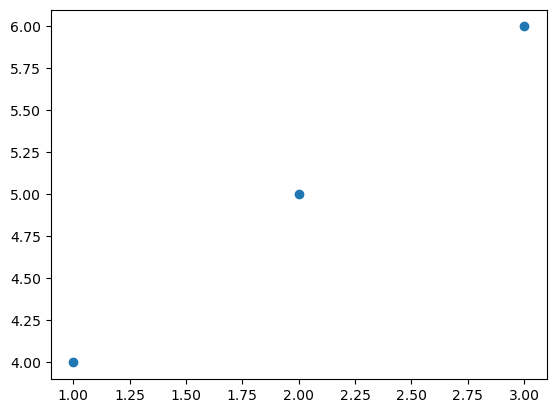

In [2]:
import matplotlib
# matplotlib 설정 객체에 강제로 _get 메서드를 심어줍니다.
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = lambda key: matplotlib.rcParams[key]

import matplotlib.pyplot as plt
%matplotlib inline

# 테스트용 그래프
plt.scatter([1, 2, 3], [4, 5, 6])
plt.show()

- 여기서 다시 강의 내용 시작

<regression model은 실수값을 예측하는 것>

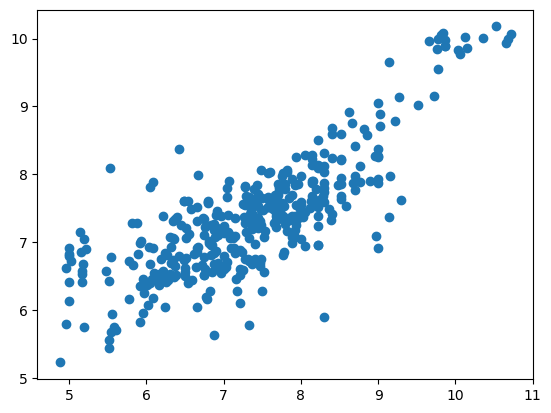

In [45]:
plt.scatter(y_test, y_pred)

- x축은 실제값(y_test) y축은 예측값(y_pred)을 의미
- 100개중 20개에 대한 학습의 결과 y_test, 80개에 대한 학습의 결과 y_train

  => 여기서 RFR에는 X_train에 대한 학습만 시킨 상태라 X_test 문제는 모름. 따라서 y_train은 이미 학습되어 정답을 알고 있는 정답지이고 이 정답지를 통해 아직 학습하지 않은 y_test가 있음. 여기서 y_test에 대한 실제 정답과(이건 내가 학습시키지 않아서 RFR은 모르지만 나는 알고 있는 정답) RFR이 진행한 X_test에 대한 예측 답안(y_pred)의 유사도를 통해 학습이 잘 되었는지 판단하기 위함.

- Scatter 그래프와 R^2의 의미

  => 우상향 직선(y=x 선): 실제값이 10일 때 모델로 10이라고 에측하면 점이 정확히 대각선 위에 찍힌다.
  => R^2이 1에 가깝다: 모든 점이 대각선에 딱 붙어 있다는 뜻이며, 모델이 정답을 거의 완벽하게 맞췄다.
  => 점들이 흩어져 있다: 모델이 실제값보다 너무 높게 혹은 낮게 엉뚱한 예측을 하고 있다.

# 정량 검증을 위해서 Mean Squared Error(성능 평가)를 계산해볼 수 있다.

> {(실제값)-(예측값)}^2

In [46]:
from sklearn.metrics import mean_squared_error as mse

In [47]:
mse(y_test, y_pred)

0.4748899347313291

In [48]:
np.sqrt(mse(y_test, y_pred))  # 제곱을 구하는 코드

0.6891225832399698

### Mean Squared Error 말고 Mean Absolute Error도 많이 사용된다. 

In [49]:
from sklearn.metrics import mean_absolute_error as mae

In [50]:
mae(y_test, y_pred)

0.5133693031786899

## R^2 값은 perfect correlation이면 1 correlation이 약해질 수록 0에 가까워진다.

> 아래의 R^2가 나타내는 0.64는 높은 편에 속한대

In [51]:
from sklearn.metrics import r2_score

In [52]:
r2_score(y_test, y_pred)

0.6423556884024924

## n_estimator 라는 hyperparameter를 바꿔서 새로운 모델을 만들어 보자!

> 위에서 학습시켰던 모델은 기본(default) 모델을 학습시켰는데, 이 모델에서 여러가지 parameter를 바꾸서 다양한 모델을 만들 수 있다.

In [54]:
# RandomForest에는 여러개의 의사결정 나무(Decision Tree)를 만들고, 그들이 내놓은 결과들을 투표나 평균을 내어 최종 결론을 내리는 모델.
# 이때, n_estimator는 의사결정 나무의 수로,n_estimator=300은 300그루의 나무에게 의견을 물어보겠다는 의미.
# 숫자가 커지면 정확도는 향상되지만 학습 시간(fit)과 예측 시간(predict)이 오래걸리고 메모리도 더 많이 필요하다.
my_model2 = RFR(n_estimators=300)

In [55]:
my_model2.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
y_pred2 = my_model2.predict(y_test)

ValueError: Expected 2D array, got 1D array instead:
array=[ 7.75  5.52  9.81  7.92  6.5   8.05  5.17  6.75  6.91  7.48  7.29  7.25
  9.15  5.55  6.38  7.39  9.14  7.08  6.4   7.89  6.16  7.28  7.68  7.49
  5.96  7.16  5.58  8.15  8.7   7.92  6.97  7.64  8.3  10.06  6.01  7.82
  7.41  7.49  6.87  9.    6.85  6.28  6.37  6.8   7.89  7.58  6.49  7.96
  5.47  8.    7.75  7.47  7.43  6.03  6.19  7.54  8.22  6.42  7.21  7.6
  7.57  7.52  7.24  7.27  6.22  7.7   7.41  7.72  7.01  8.52  8.16  7.8
 10.53  5.15  7.33  7.85  9.    7.34  4.96  6.9   7.68  7.06  7.88  8.24
  6.84  7.26  6.3   9.    8.39  6.66  9.72  6.49  9.02  7.82  6.59  6.54
  7.37  7.47  8.7   7.04  6.27  7.93  8.77  5.92  7.25  6.87  5.53  8.
  8.52  7.13  5.52  6.24  8.7   8.    9.84  7.12  6.32  6.51  6.81  7.61
  7.33  7.93  9.87  8.48  7.89  6.91  8.22  7.6   7.17  7.06  6.9   7.92
  6.72  7.33  6.07  8.3  10.66  6.65  6.75  6.04  8.52 10.12  7.78  6.08
  8.85  7.74  8.3   7.94  8.58  6.73  8.03  7.57  7.8   7.04  4.88  6.24
  5.14  6.51  6.23  8.4   7.07  6.51  7.31  8.15  5.89  7.44  7.48  9.86
  8.28  7.42  8.    6.8   6.5  10.72  7.51  6.89  7.85  5.52  8.22  7.14
  6.75  7.82  7.28  6.87  7.07  7.66  6.5   7.33  5.83  8.52  7.7   8.
  6.66  7.15  7.68  7.44  4.99  7.99  5.93  6.16  5.54  8.3   5.77  8.12
  6.96  9.3   7.37  5.    7.28  6.02  7.89  7.15  7.52  7.68  8.13  6.08
  6.05  6.34  5.97  6.37  8.52  6.34  9.02 10.15  5.98  6.22  8.36  5.22
  5.02  7.01  6.34  7.44  7.8   6.25  5.19  7.68  8.52  5.96  5.16  5.77
  7.33  6.92  7.44  9.    6.92  6.67  7.77  9.22 10.03  6.77  7.57  5.
  7.29  8.05  8.52  7.77  7.58  5.19  9.66  7.93  8.68  8.66  7.44  7.03
  7.39  4.96  7.48  7.37  7.37  8.77  6.58  6.54  8.19  9.51  9.    8.22
  5.    7.35  5.81  6.84  6.35  9.76  6.8   7.89  9.77  7.96  6.84  6.75
 10.68  7.47  5.88  7.37  7.75  6.24  9.86  6.65  8.3   8.89  7.85  8.15
  8.96  8.15  8.3   5.54  6.49  6.66  7.42  7.36  8.22  7.85  9.27  5.91
  6.74  7.78  8.62  8.4   6.13  8.3   5.16  6.64  8.3   6.76  6.55  7.92
  6.42  7.43  7.21  6.36  8.05  7.39  6.32  8.15  8.22  8.4   8.22  6.82
  6.62  6.92  9.14  7.77  6.1   7.38  6.04  9.    6.93  7.    7.48  7.77
  8.22  6.76  7.    8.82  7.04  5.18  6.9   6.09  5.    7.65  7.64  6.87
  6.3   8.22  9.    8.4   6.45  7.28  7.21  6.79  6.88  8.97  8.15  7.31
 10.36  6.67  7.7   5.91  6.81  7.73  9.77  7.09  6.85  7.21  5.6 ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

# Troubleshooting
predict(X) => 여기서 X는 예측할 문제를 의미

In [58]:
y_pred2 = my_model2.predict(X_test)

* Error가 조금 더 작다는 거는 두번째 모델이 조금 더 좋은 모델이라는 것

In [59]:
mse(y_test, y_pred2)

0.4638492164185989

In [60]:
mae(y_test, y_pred2)

0.5104097988965883

In [61]:
r2_score(y_test, y_pred2)

0.6506705626748486

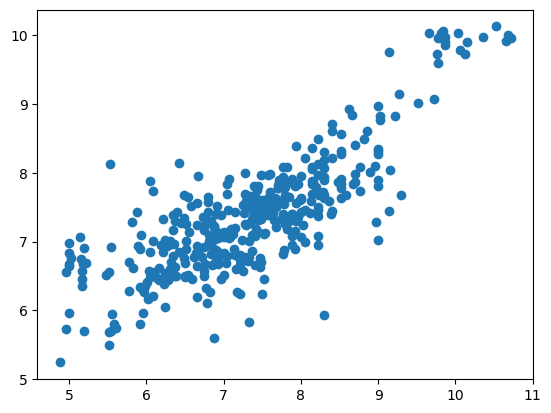

In [62]:
plt.scatter(y_test, y_pred2)

# 어떤 모델이 최적이냐?

=> 이것을 알아내는 과정이 Hyperparameter tuning

=> Hyperparameter tuning은 최근에는 자동화된 tuning 등장하였음.

> pandas 학습해보기
https://pandas.pydata.org/